In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

In [19]:
import os
os.listdir()


['.config',
 'shop-wise-trans-details_4_2024.csv',
 'shop-wise-trans-details_4_2023.csv',
 'fpshop-card-status_10_2023.csv',
 'shop-wise-trans-details_10_2024.csv',
 'clustered_fps_data.csv',
 'shop-wise-trans-details_3_2023.csv',
 'sample_data']

In [20]:
df = pd.read_csv("shop-wise-trans-details_3_2023.csv")

df.head()

,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,riceFsc,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt
0,532,Adilabad,532001,Talamadugu,1901001,3,2023,955,955,1295.0,14520.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28
1,532,Adilabad,532001,Talamadugu,1901002,3,2023,533,533,665.0,8425.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33
2,532,Adilabad,532001,Talamadugu,1901003,3,2023,269,269,560.0,4145.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18
3,532,Adilabad,532001,Talamadugu,1901004,3,2023,359,360,490.0,5920.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,8
4,532,Adilabad,532001,Talamadugu,1901005,3,2023,905,905,5355.0,13300.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23


In [21]:
numeric_cols = df.select_dtypes(include=np.number)

X = numeric_cols.fillna(0)

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [22]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(
silhouette_score(
X_scaled,
clusters
))



0.4246704145882887


In [23]:
dbscan = DBSCAN()

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN"] = db_labels

df.head()

,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,...,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt,Cluster,DBSCAN
0,532,Adilabad,532001,Talamadugu,1901001,3,2023,955,955,1295.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28,2,-1
1,532,Adilabad,532001,Talamadugu,1901002,3,2023,533,533,665.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33,3,0
2,532,Adilabad,532001,Talamadugu,1901003,3,2023,269,269,560.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18,3,0
3,532,Adilabad,532001,Talamadugu,1901004,3,2023,359,360,490.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,8,3,1
4,532,Adilabad,532001,Talamadugu,1901005,3,2023,905,905,5355.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2,-1


In [24]:
dbscan = DBSCAN()

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN"] = db_labels

df.head()

,distCode,distName,officeCode,officeName,shopNo,month,year,noOfRcs,noOfTrans,riceAfsc,...,riceAap,wheat,sugar,rgdal,kerosene,totalAmount,salt,otherShopTransCnt,Cluster,DBSCAN
0,532,Adilabad,532001,Talamadugu,1901001,3,2023,955,955,1295.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28,2,-1
1,532,Adilabad,532001,Talamadugu,1901002,3,2023,533,533,665.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,33,3,0
2,532,Adilabad,532001,Talamadugu,1901003,3,2023,269,269,560.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18,3,0
3,532,Adilabad,532001,Talamadugu,1901004,3,2023,359,360,490.0,...,10.0,0.0,0.0,0.0,0.0,0.0,0.0,8,3,1
4,532,Adilabad,532001,Talamadugu,1901005,3,2023,905,905,5355.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23,2,-1


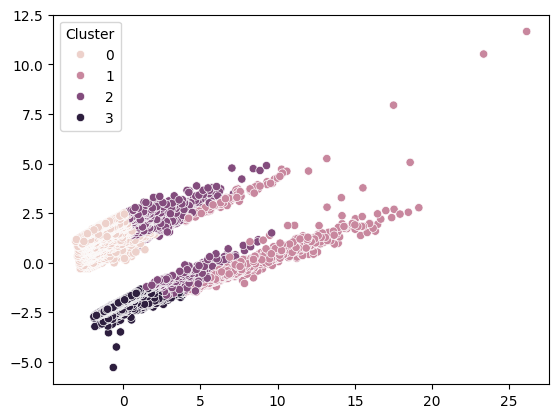

In [25]:
sns.scatterplot(
x=X_pca[:,0],
y=X_pca[:,1],
hue=df["Cluster"]
)

plt.show()

In [26]:
df.to_csv(
"clustered_fps_data.csv",
index=False
)

In [29]:
print(df.columns)

Index(['distCode', 'distName', 'officeCode', 'officeName', 'shopNo', 'month',
       'year', 'noOfRcs', 'noOfTrans', 'riceAfsc', 'riceFsc', 'riceAap',
       'wheat', 'sugar', 'rgdal', 'kerosene', 'totalAmount', 'salt',
       'otherShopTransCnt', 'Cluster', 'DBSCAN'],
      dtype='object')
